# PPP online tool (simplified version of PPP)

This tool is used to help PFS users know the expected completeness rates and fiber usage fractions of their samples in the proposal prepation phase. The tool is the simplified version of full PPP. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output
import glob
import seaborn as sns
from astropy import units as u
from astropy.coordinates import SkyCoord
import collections
from shapely.geometry import Point
from matplotlib.path import Path
import colorcet as cc
from itertools import chain
from sklearn.cluster import DBSCAN

#below for netflow
from __future__ import print_function
import ets_fiber_assigner.netflow as nf
from ics.cobraOps.Bench import Bench
from ics.cobraOps.TargetGroup import TargetGroup
from ics.cobraOps.CobrasCalibrationProduct import CobrasCalibrationProduct
from ics.cobraOps.CollisionSimulator import CollisionSimulator
from ics.cobraOps.cobraConstants import NULL_TARGET_POSITION, NULL_TARGET_ID
from ics.cobraOps import plotUtils
from collections import defaultdict

# read user sample & reference sample

In [3]:
def readSamples(direc,Print):
    '''Read reference samples from the files: 
    in format of #ID, #RA, #DEC, #exposure in sec, #ScienceGrade, #length, #note1, #note2

    Parameters
    ==========
    direc : string
        the name of directory containing sample lists

    Returns
    =======
    list of reference targets
    '''
    dir_=glob.glob(direc+'/*')
    if len(dir_)==0:
        dir_=[direc]
    allSamp=[]
    conA=0
    conB=0
    for l in dir_:
        temp=np.loadtxt(l,dtype='str')
        # convert rank: rankA=3, rankB=2, rankC=1 (currently Calib=0)
        if temp[0][4]=='A':
            rank=3
            rank_t='A'+str(conA+1)
            conA+=1
        elif temp[0][4]=='B':
            rank=2
            rank_t='B'+str(conB+1)
            conB+=1
        if Print==True:print(l,rank_t,rank)
        for i in temp:
            if float(i[2])<-15 or float(i[2])>80:continue
            ID,ra,dec,exp=i[0],float(i[1]),float(i[2]),float(i[3])             
            # currently one exposure set to be 900 sec.   
            allSamp.append([ID,ra,dec,exp/900.,rank,rank_t,"ref"])  
    return np.array(allSamp, dtype="O") 

def readUserSample(direc,direc_ref,Print):
    '''Read user sample from the file: 
    in format of #ID, #RA, #DEC, #exposure in sec, #UserPriority, #length, #note1, #note2
    #UserPriority should be intergers from 9 to 0, with 9 the highest and 0 the lowest priority

    Parameters
    ==========
    direc : string
        the name of user sample
    direc_ref: string
        the name of reference samples

    Returns
    =======
    list of user+reference samples in the case that user sample is given Grade A/B/classic
    ('A' means it is accepted, and among the highest priority samples;
    'B' means it is accepted, and among the lower priority samples;
    'classic' means it is accepted, and will be taken under classic mode.)
    '''
    time_start=time.time()

    dir_=direc#glob.glob(direc+'/*')
    print("#Please confirm your sample is",dir_)      
    if len(dir_)==0:
        dir_=[direc]
    if direc_ref!='reference_s/1':
        sample_ref=readSamples(direc_ref,False)
        samp=[name for name,con in collections.Counter(sample_ref.T[-2]).items()]
        conA,conB=[len([1 for tt in samp if tt[0]==ww]) for ww in ['A','B']]
        
        usrSampRA=[qq for qq in sample_ref]
        usrSampRB=[qq for qq in sample_ref]
        usrSampCla=[]
        for l in range(len(dir_)):
            rank_t_ra='A'+str(int(conA+1+l))
            rank_t_rb='B'+str(int(conB+1+l))
            rank_t_cla='A'+str(int(l+1))
            temp=np.loadtxt(dir_[l],dtype='str')
            for i in temp:
                if float(i[2])<-15 or float(i[2])>80:continue
                ID,ra,dec,exp,P_user='Usr'+i[0],float(i[1]),float(i[2]),float(i[3]),float(i[4])
                usrSampRA.append([ID,ra,dec,exp/900.,2.1+0.1*P_user,rank_t_ra,"usr"])  
                usrSampRB.append([ID,ra,dec,exp/900.,1.1+0.1*P_user,rank_t_rb,"usr"])  
                usrSampCla.append([ID,ra,dec,exp/900.,2.1+0.1*P_user,rank_t_cla,"usr"])  
        print("#Step 1/3: Read in samples DONE! (takes",round(time.time()-time_start,3),"sec)")
    elif direc_ref=='reference_s/1':
        sample_ref_=readSamples(direc_ref,False)
        samp=[name for name,con in collections.Counter(sample_ref_.T[-2]).items()]
        conA,conB=[len([1 for tt in samp if tt[0]==ww]) for ww in ['A','B']]
        
        usrSampCla=[]
        for l in range(len(dir_)):
            rank_t_ra='A'+str(int(conA+1+l))
            rank_t_rb='B'+str(int(conB+1+l))
            rank_t_cla='A'+str(int(l+1))
            temp=np.loadtxt(dir_[l],dtype='str')
            
            allusr= np.radians([[float(temp[ii,2]),float(temp[ii,1])] for ii in range(len(temp))])  
            db = DBSCAN(eps=np.radians(1.38), min_samples=1, metric='haversine').fit(allusr)
    
            labels = db.labels_
            unique_labels = set(labels)
            n_clusters = len(unique_labels)
    
            usr_group=[]
            for jj in range(n_clusters):
                group_tt=[allusr[uu] for uu in range(len(allusr)) if labels[uu]==jj]
                if len(group_tt)>len(temp)*0.1:
                    usr_group.append([np.mean(np.degrees(group_tt)[:,1]),np.mean(np.degrees(group_tt)[:,0])])
            
            if len(usr_group)==0:
                usr_group.append([np.degrees(allusr)[0,1],np.degrees(allusr)[0,0]])
            count_g=int(len(sample_ref_)/len(usr_group))
            
            for kk in range(len(usr_group)):
                sample_ref_[count_g*kk:count_g*(kk+1),1]+=usr_group[kk][0]
                sample_ref_[count_g*kk:count_g*(kk+1),2]+=usr_group[kk][1]
            
            usrSampRA=[qq for qq in sample_ref_]
            usrSampRB=[qq for qq in sample_ref_]
    
            for i in temp:
                if float(i[2])<-15 or float(i[2])>80:continue
                ID,ra,dec,exp,P_user='Usr'+i[0],float(i[1]),float(i[2]),float(i[3]),float(i[4])
                usrSampRA.append([ID,ra,dec,exp/900.,2.1+0.1*P_user,rank_t_ra,"usr"])  
                usrSampRB.append([ID,ra,dec,exp/900.,1.1+0.1*P_user,rank_t_rb,"usr"])  
                usrSampCla.append([ID,ra,dec,exp/900.,2.1+0.1*P_user,rank_t_cla,"usr"])  
        print("#Step 1/3: Read in samples DONE! (takes",round(time.time()-time_start,3),"sec)")
    return np.array(usrSampRA, dtype="O"),np.array(usrSampRB, dtype="O") ,np.array(usrSampCla, dtype="O")

# determine pointing centers

In [4]:
def count_N(sample):
    '''calculate local count of targets

    Parameters
    ==========
    sample : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")

    Returns
    =======
    2d array of count (bin_width is 2 deg in ra&deg)
    '''
    count_bin=[ [ 0 for i in np.arange(0,361,2) ] for j in np.arange(-15,80,2) ]
    for tt in range(len(sample)):
        if sample.T[2][tt]<-15 or sample.T[2][tt]>80: continue
        m= int(sample.T[1][tt]/2.) 
        n= int((sample.T[2][tt]+15)/2.)-1
        count_bin[n+1][m]+=1
    return count_bin

def weight(sample,count_sam,conta,contb,contc): 
    '''calculate weights of targets

    Parameters
    ==========
    sample : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; contb--> remaining time; contc--> local density
    count_sam: 2d array
        output from count_N
        
    Returns
    =======
    list of weights
    '''
    if len(sample)>1:
        rank=sample.T[4]
        leng=np.array([count_sam[int((sample.T[2][ii]+15)/2.)][int(sample.T[1][ii]/2.)] for ii in range(len(sample))])
        time_remain=sample.T[3]
        wei=pow(conta,rank)*pow(time_remain,contb)*pow(leng,contc)
    elif len(sample)==1:
        rank=sample[0][4]
        leng=count_sam[int((sample[0][2]+15)/2.)][int(sample[0][1]/2.)]
        time_remain=sample[0][3]
        #print(rank,leng,time_remain)
        wei=[pow(conta,rank)*pow(time_remain,contb)*pow(leng,contc)]
    return wei

def PFS_FoV_plot(raP,decP,PA,line_color,line_width,line_st):
    '''plot PFS FoV (hexagon)

    Parameters
    ==========
    raP,decP,PA : float
        ra,dec,PA of the pointing center
    line_color,line_st: string
        color and style of the plotting
    line_width: float
        width of the edge of the pointing
        
    Returns
    =======
    plot a hexagon at the pointing center with diameter=1.38 deg
    '''
    center=SkyCoord(raP*u.deg,decP*u.deg)
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    ra_h_in=np.where(np.fabs(ra_h-center.ra.deg)>180)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
        elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
    plt.plot(ra_h,dec_h,color=line_color,lw=line_width,ls=line_st,alpha=0.5,zorder=5)
    
def PFS_FoV(ra,dec,PA,sample):
    '''pick up targets in the pointing

    Parameters
    ==========
    ra,dec,PA : float
        ra,dec,PA of the pointing center
    sample : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")
        
    Returns
    =======
    list of index of targets, which fall into the pointing, in the input sample
    '''
    point=np.vstack((sample.T[1],sample.T[2])).T.astype('float')
    center=SkyCoord(ra*u.deg,dec*u.deg)
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    ra_h_in=np.where(np.fabs(ra_h-center.ra.deg)>180)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
        elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
    polygon = Path([(ra_h[t],dec_h[t]) for t in range(len(ra_h))])
    index_=np.where(polygon.contains_points(point)==True)[0]
    return index_

def PPP_centers(sample,Npoint,conta,contb,contc,Print,Plot):
    '''determine pointing centers

    Parameters
    ==========
    sample : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")
    Npoint : integer
        total number of pointings
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; contb--> remaining time; contc--> local density
        
    Returns
    =======
    list of pointing centers
    '''
    time_start=time.time()
    Nfiber=int(2394*0.7) #simulate that 70% of fibers can be allocated
    
    if Print==True:
        samp=[name for name,con in collections.Counter(sample.T[-2]).items()]
        samp.sort()
        sampling_full=np.array([collections.Counter(sample.T[-2])[ee] for ee in samp])
        Na,Nb=[sum([collections.Counter(sample.T[-2])[ee] for ee in samp if ee[0]==ww]) for ww in ['A','B']]
        sampling=[0]*len(samp)

    ii=0
    peak=[]
    
    sample_s=np.array([sample[ooo] for ooo in range(len(sample)) if sample[ooo,3]>0])
    count_sam=count_N(sample_s)
    weight_s=weight(sample_s,count_sam,conta,contb,contc)
    cons=0
        
    while ii<=Npoint and len([1 for ooo in range(len(sample_s)) if sample_s[ooo,3]>0])>0:
        #-------------------------------
        ####peak_xy from random object positions with weights
        ittt=random.choices(np.arange(0,len(sample_s),1),weights=weight_s.astype(float),k=1)
        peak_x,peak_y=sample_s[ittt[0]][1],sample_s[ittt[0]][2]
        peak.append([peak_x,peak_y])
        #-------------------------------
        index_=PFS_FoV(peak_x,peak_y,0,sample_s) #all PA set to be 0
        if len(index_)>Nfiber:
            index_=random.sample(list(index_), Nfiber)
        sample_s[list(index_),3]-=1
            
        for tt in index_:
            if sample_s[tt,3]>0:
                continue
            elif sample_s[tt,3]==0:
                m= int(sample_s.T[1][tt]/2.) 
                n= int((sample_s.T[2][tt]+15)/2.)-1
                count_sam[n+1][m]-=1
                
                cons+=1
                weight_s[tt]=0
                sample_s.T[1][tt]=-999
                sample_s.T[2][tt]=-999
                
        for tt in index_:
            if sample_s[tt,3]>0:
                weight_s[tt]=weight([sample_s[tt]],count_sam,conta,contb,contc)[0]
    
        if Print==True:
            #check sampling & efficiency------------------------------
            sampling+=np.array([len([1 for rr in list(index_) if sample_s[rr,-2]==samp[o] and sample_s[rr,3]==0]) \
                        for o in range(len(samp))])
            sampling_rABC=[sum([sampling[ee] for ee in range(len(samp)) if samp[ee][0]==ww]) for ww in ['A','B']]
            if ii%25==0 and Na*Nb!=0 and Print==True:
                print(str(ii),len(index_),len(sample_s)-cons,\
                      peak_x,peak_y, "RankA=","{:2.2f}%".format(100*sampling_rABC[0]/Na),\
                  ", RankB=","{:2.2f}%".format(100*sampling_rABC[1]/Nb))
            elif ii%25==0 and Print==True:
                print(str(ii),len(index_),len(sample_s)-cons,peak_x,peak_y, "RankA=","{:2.2f}%".format(100*sampling_rABC[0]/Na),\
                  ", RankB=","{:2.2f}%".format(999))
        ii+=1
    
    print("#Step 2/3: Determine pointing centers DONE! (takes",round(time.time()-time_start,3),"sec)")
    if Plot==True:
        print("  Your sample (red) and the reference sample (black), with the pointings (cyan):")
        plt.plot(sample.T[1],sample.T[2],'k.',ms=0.2)
        plt.plot([sample[uuu][1] for uuu in range(len(sample)) if sample[uuu][-1]=='usr'],\
                [sample[uuu][2] for uuu in range(len(sample)) if sample[uuu][-1]=='usr'],'ro',ms=2)
        for ii in range(len(peak)):
            PFS_FoV_plot(peak[ii][0],peak[ii][1],0,'c',0.5,'-')
        plt.xlim(min(sample.T[1]),max(sample.T[1]))
        plt.ylim(min(sample.T[2]),max(sample.T[2]))
        plt.xlabel('RA',fontsize=10)
        plt.ylabel('DEC',fontsize=10)
        plt.show()
    return peak

# netflow part

In [5]:
def point_DBSCAN(peak,Plot):
    '''separate pointings into different group

    Parameters
    ==========
    peak : array
        list of pointing centers
        
    Returns
    =======
    list of pointing centers in different group
    '''

    peak1= np.radians([[peak[ii][1],peak[ii][0]] for ii in range(len(peak))])   ####haversine uses (dec,ra) in radian; 
    db = DBSCAN(eps=np.radians(1.38), min_samples=1, metric='haversine').fit(peak1)
    
    labels = db.labels_
    unique_labels = set(labels)
    n_clusters = len(unique_labels)
    print("There are",len(peak),"pointings, they are grouped into",n_clusters,"clusters.")
    
    peak_group=[]
    for ii in range(n_clusters):
        peak_=[peak[uu] for uu in range(len(peak)) if labels[uu]==ii]
        peak_group.append(peak_)

    if Plot==True:
        colors = sns.color_palette(cc.glasbey_warm, n_clusters)
        for k, col in zip(unique_labels, colors):
            class_member_mask = (labels == k)
            xy = peak[class_member_mask ]
            for uu in xy:
                PFS_FoV_plot(uu[0], uu[1],0,col,0.2,'-')
                plt.plot(uu[0],uu[1],'o',mfc=col,mew=0,ms=0.4)
        plt.show()
    return peak_group

def sam2netflow(sample,prefix,conta,contb,contc):######need consider F-star ??
    '''put targets to the format which can be read by netflow

    Parameters
    ==========
    sample : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")
    prefix: string
        "sci" or "calib"
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; contb--> remaining time; contc--> local density
        
    Returns
    =======
    list of targets
    '''
    res=[]
    count_sam=count_N(sample)
    weight_te=weight(sample,count_sam,conta,contb,contc)
    cc_=0
    for tt in sample:
        id_, ra, dec, tm, pri = (tt[0], float(tt[1]), float(tt[2]),float(tt[3])*900.0, cc_)
        res.append(nf.ScienceTarget(id_, ra, dec, tm, pri, prefix))
        cc_+=1
    return res

def NetflowPreparation(sample,conta,contb,contc):######need consider F-star ??
    '''assign cost to each target

    Parameters
    ==========
    sample : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; contb--> remaining time; contc--> local density
        
    Returns
    =======
    class of targets with costs, list of cost of all targets
    '''
    samp=[name for name,con in collections.Counter(sample.T[-2]).items()]
    samp.sort()
    
    count_sam=count_N(sample)
    weight_tem=weight(sample,count_sam,conta,contb,contc)
    classdict = {}
    for yy in range(len(weight_tem)):
        classdict["sci_P"+str(yy)] = {"nonObservationCost": float(weight_tem[yy]),
                           "partialObservationCost": float(weight_tem[yy])*1.5, "calib": False}
    return classdict,weight_tem

def netflowRun(peak,sample,t_obs,posang,nvisit,gurobiPa,conta,contb,contc):
    '''assign cost to each target

    Parameters
    ==========
    peak : array
        list of pointing centers
    sample : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")
    t_obs: float
        one exposure in sec
    posang: float
        PA, set to be 0
    nvisit: float
        total number of pointing
    gurobiPa:
        set of Gurobi parameters
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; contb--> remaining time; contc--> local density
        
    Returns
    =======
    list of fiber allocation fraction of all of the pointings, 
    list of fiber allocation fraction of the pointings covering the user targets, 
    objective of the netflow problem,
    fiber assignment of each pointing
    '''
    print("#Step 3/3: Start running netflow to assign fibers")
    time_start=time.time()
    peak_gg=point_DBSCAN(peak,False)
    fib_eff=[]  
    fib_eff1=[]
    obj_allo=[]
    
    for uu in range(len(peak_gg)):
        Telra=[peak_gg[uu][yy][0] for yy in range(len(peak_gg[uu]))]
        Teldec=[peak_gg[uu][yy][1] for yy in range(len(peak_gg[uu]))]
        sample_index=list(chain.from_iterable([list(PFS_FoV(Telra[iii],Teldec[iii],0,sample)) for iii in range(len(Telra))]))
        sample_inuse=sample[list(set(sample_index))]
        print("##Now is Group",uu,", it contains",len(peak_gg[uu]),"pointings, and",len(sample_inuse),"targets.")
    
        bench = Bench(layout="full")
        tgt=sam2netflow(sample_inuse,'sci',conta,contb,contc)
        classdict,weight_t=NetflowPreparation(sample_inuse,conta,contb,contc)
        otime = "2016-04-03T08:00:00"
        telescopes = []
    
        for kk in range(min(nvisit,len(Telra))):
            telescopes.append(nf.Telescope(Telra[kk], Teldec[kk], posang, otime))
        tpos = [tele.get_fp_positions(tgt) for tele in telescopes]

        # optional: slightly increase the cost for later observations,
        # to observe as early as possible
        vis_cost = [1 for i in range(nvisit)]

        # optional: penalize assignments where the cobra has to move far out
        def cobraMoveCost(dist):
            return 0.1*dist

        gurobiOptions = gurobiPa

        # partially observed? no
        alreadyObserved={}

        # compute observation strategy
        prob = nf.buildProblem(bench, tgt, tpos, classdict, t_obs,
                           vis_cost, cobraMoveCost=cobraMoveCost,
                           collision_distance=2., elbow_collisions=True,
                           gurobi=True, gurobiOptions=gurobiOptions,
                           alreadyObserved=alreadyObserved)

        #print("solving the problem")
        prob.solve()
        Obj=prob._prob.objVal

        # extract solution
        res = [{} for _ in range(min(nvisit,len(Telra)))]
        for k1, v1 in prob._vardict.items():
            if k1.startswith("Tv_Cv_"):
                visited = prob.value(v1) > 0
                if visited:
                    _, _, tidx, cidx, ivis = k1.split("_")
                    res[int(ivis)][int(tidx)] = int(cidx)

        #print fiber assign
        for i, (vis, tp, tel) in enumerate(zip(res, tpos, telescopes)):
            fib_eff_t=len(vis)/2394.*100
            fib_eff.append(fib_eff_t)
            print("exposure {}:".format(i))
            print("  assigned Cobras(%): {:.2f}%".format(fib_eff_t))
            
            tem_fib=0
            for tidx, cidx in vis.items():
                obj_allo.append(["Group_"+str(uu+1),"Point_"+str(i+1), tel._ra, tel._dec, tel._posang,tgt[tidx].ID,
                                 cidx+1, tp[tidx].real,tgt[tidx].ra, tgt[tidx].dec,
                                 tgt[tidx].targetclass[5:]])
                if tgt[tidx].ID[:3]=='Usr':tem_fib+=1
            if tem_fib>0:fib_eff1.append(fib_eff_t)
    print("#Step 3/3: Run netflow DONE! (takes",round(time.time()-time_start,3),"sec)")
    return fib_eff,fib_eff1,Obj,obj_allo 

# run the codes & check outputs & Plot results

In [6]:
def output(sampp,Npoint,ref_cla):
    '''run the codes for one input sample 

    Parameters
    ==========
    sampp : array
        list of targets (ID,ra,dec,exp,ScienceGrade,rank(Ax or Bx),"ref"or"usr")
    Npoint: float
        total number of pointing
    ref_cla: string
        reference sample catagory, '1'/'2'/'3'
        
    Returns
    =======
    list of pointing centers,
    list of fiber allocation fraction of all of the pointings, 
    list of fiber allocation fraction of the pointings covering the user targets, 
    objective of the netflow problem,
    fiber assignment of each pointing
    '''
    if ref_cla=="1":
        conta,contb,contc=8.33,0.09,0.04 #optimal weighting parameters in case 1
    elif ref_cla=="2":
        conta,contb,contc=4.02,0.22,0.15 #optimal weighting parameters in case 2
    elif ref_cla=="3":
        conta,contb,contc=6.34,0.12,0.11 #optimal weighting parameters in case 3
    peak=PPP_centers(sampp,Npoint,conta,contb,contc,False,True)
    gurobiPa=dict(seed=0, presolve=1, method=0, degenmoves=0,heuristics=0.6, mipfocus=0, mipgap=5.0e-2,LogToConsole=0)
    fib_eff,fib_eff1,Obj,obj_allo=netflowRun(peak,sampp,900,0,Npoint,gurobiPa,conta,contb,contc)
    return peak,fib_eff,fib_eff1,Obj,obj_allo 

def write_Fassign(usr,ref,rank,samp_allo_ra,samp_allo_rb,samp_allo_rcl):
    '''write the final fiber assignment to file

    Parameters
    ==========
    usr : string
        the name of the user sample
    ref: string
        reference sample catagory, '1'/'2'/'3'
    rank: string
        the simulated grade given to the user sample, 'A'/'B'/'cla'
        ('A' means it is accepted, and among the highest priority samples;
         'B' means it is accepted, and among the lower priority samples;
         'cla' means it is accepted, and will be taken under classic mode.)
        
    Returns
    =======
    list of pointing centers,
    list of fiber allocation fraction of all of the pointings, 
    list of fiber allocation fraction of the pointings covering the user targets, 
    objective of the netflow problem,
    fiber assignment of each pointing
    '''
    newFile=open('output/'+usr+"_r"+rank+"_ref"+ref,'w')
    newFile.write("#$1 Pointing Group; $2 Pointing N; $3 RA_point; $4 DEC_point; $5 PA_point; $6 target_ID; $7 fiber_n; $8 target_RA; $9 target_DEC \n")
    if rank=='A':
        for uu in samp_allo_ra:
            if uu[5][:3]=='Usr':
                newFile.write(str(uu[0])+"\t"+str(uu[1])+"\t"+str(uu[2])+"\t"+str(uu[3])+"\t"+str(uu[4])+"\t"+str(uu[5])+"\t"+str(uu[6])+"\t"+str(uu[8])+"\t"+str(uu[9])+"\n")
    elif rank=='B':
        for uu in samp_allo_rb:
            if uu[5][:3]=='Usr':
                newFile.write(str(uu[0])+"\t"+str(uu[1])+"\t"+str(uu[2])+"\t"+str(uu[3])+"\t"+str(uu[4])+"\t"+str(uu[5])+"\t"+str(uu[6])+"\t"+str(uu[8])+"\t"+str(uu[9])+"\n")
    elif rank=='cla':
        for uu in samp_allo_rcl:
            if uu[5][:3]=='Usr':
                newFile.write(str(uu[0])+"\t"+str(uu[1])+"\t"+str(uu[2])+"\t"+str(uu[3])+"\t"+str(uu[4])+"\t"+str(uu[5])+"\t"+str(uu[6])+"\t"+str(uu[8])+"\t"+str(uu[9])+"\n")
    newFile.close()
    
def complete(sampleRR,sample_out):
    '''examine the completeness fraction of the user sample

    Parameters
    ==========
    sampleRR : array
        the combined user + reference sample in one grade, 'A'/'B'/'cla'
    sample_out: array
        the final fiber assignment of each pointing
        
    Returns
    =======
    list of (completed fraction, completed + partial completed fraction) of the user sample in one grade, 'A'/'B'/'cla'; inner user priority is considered
    '''
    sample_usr=np.array([uu for uu in sampleRR if uu[-1]=='usr'])
    sample_=np.array([uu for uu in sample_usr])
    for qq in range(len(sample_out)):
        if sample_out[qq][5][:3]!='Usr':continue
        sample_.T[3][int(sample_out[qq][5].replace('_',' ').split()[-1])]-=1
    
    comp_out=[]
    for rannk in np.arange(0,10,1):
        tot=len([1 for ii in range(len(sample_)) if int((sample_[ii][-3]-int(sample_[ii][-3]))*10)==rannk])
        done,undone,part=[len([1 for ii in range(len(sample_)) if sample_[ii][3]<=0 and int((sample_[ii][-3]-int(sample_[ii][-3]))*10)==rannk]),\
                    len([1 for ii in range(len(sample_)) if sample_[ii][3]==sample_usr[ii][3] and int((sample_[ii][-3]-int(sample_[ii][-3]))*10)==rannk]),\
                    len([1 for ii in range(len(sample_)) if sample_[ii][3]<sample_usr[ii][3] and sample_[ii][3]>0 \
                        and int((sample_[ii][-3]-int(sample_[ii][-3]))*10)==rannk])]
        if tot!=0:
            comp_out.append([done/tot,(done+part)/tot])
        elif tot==0:
            comp_out.append([0,0])
    return comp_out

In [7]:
def execu(npoint,writeTF,plotTF):
    '''run the codes for the three simulated case, i.e., the user sample is assigned to be Grade A/B/classic 

    Parameters
    ==========
    npoint: float
        total number of pointing
    writeTF: True or False
        whether or not to output the fiber assignment to file
    plotTF: True or False
        whether or not to plot the completed fraction and fiber allocation fraction
        
    Returns
    =======
    the fiber assignment file of the user sample,
    the figure of:
    left) the sky distribution of user sample (red), reference sample (black) and pointings (cyan),
    middle) the completed fraction if the user sample is Grade A (red), B (orange) and classic mode (grey); for each grade, the histograms reflect the user inner priority of 0 (lowest pri) to 9 (highest pri) from left to right,
    right) the fiber allocation fraction of all of the pointings covering the user sample under the queue mode (Grade A case; red) and the classic mode (grey)
    '''
    usr_file=input("Please input the name of your file:")
    ref_class=input("Please choose the refererence samples: \n case 1 -- compactly-distributed random mocks (please be careful it can take long time ~30 min); \n case 2 -- widely-distributed random mocks; \n case 3 -- simulated real queue \n")
    
    time_s=time.time()
    sampleRA,sampleRB,sampleCla=readUserSample(['user_s/'+usr_file],'reference_s/'+ref_class,True)
    
    peak_ra,fib_ra,fib1_ra,Obj_v_ra,samp_allo_ra=output(sampleRA,npoint,ref_class)
    peak_rb,fib_rb,fib1_rb,Obj_v_rb,samp_allo_rb=output(sampleRB,npoint,ref_class)
    peak_rcl,fib_rcl,fib1_rcl,Obj_v_rcl,samp_allo_rcl=output(sampleCla,npoint,ref_class)
    
    comp_outA=complete(sampleRA,samp_allo_ra)
    comp_outB=complete(sampleRB,samp_allo_rb)
    comp_outCla=complete(sampleCla,samp_allo_rcl)
    
    print("##In total, it takes",time.time()-time_s,"sec.")
    
    if writeTF==True:
        write_Fassign(usr_file,ref_class,'A',samp_allo_ra,samp_allo_rb,samp_allo_rcl)
        write_Fassign(usr_file,ref_class,'B',samp_allo_ra,samp_allo_rb,samp_allo_rcl)
        write_Fassign(usr_file,ref_class,'cla',samp_allo_ra,samp_allo_rb,samp_allo_rcl)
    
    if plotTF==True:
        clear_output(wait=True)
        print("##In total, it takes",time.time()-time_s,"sec.")
        
        plt.figure(figsize=(15,4))

        plt.subplot(131)
        plt.plot(sampleRA.T[1],sampleRA.T[2],'k.',ms=0.2)
        plt.plot([sampleRA[uuu][1] for uuu in range(len(sampleRA)) if sampleRA[uuu][-1]=='usr'],\
                [sampleRA[uuu][2] for uuu in range(len(sampleRA)) if sampleRA[uuu][-1]=='usr'],'ro',ms=0.5,zorder=10)
        for ii in range(len(peak_ra)):
            PFS_FoV_plot(peak_ra[ii][0],peak_ra[ii][1],0,'c',0.5,'-')
        plt.xlim(min(sampleRA.T[1]),max(sampleRA.T[1]))
        plt.ylim(min(sampleRA.T[2]),max(sampleRA.T[2]))
        plt.xlabel('RA',fontsize=15)
        plt.ylabel('DEC',fontsize=15)
        
        plt.subplot(132)
        ccc=0
        for ii in np.arange(0.4,1.4,0.1):
            plt.bar([ii],comp_outA[ccc][0],width=0.05,fc='tomato',ec='none',alpha=1,zorder=10)
            plt.bar([ii],comp_outA[ccc][1],width=0.05,ec='tomato',fc='none',lw=1)
            ccc+=1
        ccc=0
        for ii in np.arange(1.5,2.5,0.1):
            plt.bar([ii],comp_outB[ccc][0],width=0.05,fc='orange',ec='none',alpha=1,zorder=10)
            plt.bar([ii],comp_outB[ccc][1],width=0.05,ec='orange',fc='none',lw=1)
            ccc+=1
        ccc=0
        for ii in np.arange(2.6,3.6,0.1):
            plt.bar([ii],comp_outCla[ccc][0],width=0.05,fc='grey',ec='none',alpha=1,zorder=10)
            plt.bar([ii],comp_outCla[ccc][1],width=0.05,ec='grey',fc='none',lw=1)
            ccc+=1
        plt.plot([0,10],[0.8,0.8],'k--',lw=2,zorder=11)
        plt.xlim(0,4)
        plt.ylim(0,1.1)
        plt.xticks([0.9,2,3.1],['A','B','classic'],fontsize=15)
        plt.ylabel('completeness fraction',fontsize=15)
        plt.grid()

        plt.subplot(133)
        plt.bar(np.arange(0,len(fib1_ra),1),[UU for UU in fib1_ra],width=0.8,fc='tomato',ec='none',alpha=0.6,zorder=10)
        plt.bar(np.arange(0,len(fib1_rcl),1),fib1_rcl,width=0.8,fc='grey',ec='none',alpha=0.5)
        plt.plot([0,max([len(fib1_ra),len(fib1_rcl)])],[80,80],'k--',lw=2,zorder=11)
        plt.plot([0,max([len(fib1_ra),len(fib1_rcl)])],[np.mean(fib1_ra),np.mean(fib1_ra)],'--',color='tomato',lw=2,zorder=11)
        plt.plot([0,max([len(fib1_ra),len(fib1_rcl)])],[np.mean(fib1_rcl),np.mean(fib1_rcl)],'--',color='grey',lw=2,zorder=11)
        plt.text(max([len(fib1_ra),len(fib1_rcl)])*0.8,90,"{:2.2f}%".format(np.mean(fib1_ra)),color='tomato',fontsize=12)
        plt.text(max([len(fib1_ra),len(fib1_rcl)])*0.8,95,"{:2.2f}%".format(np.mean(fib1_rcl)),color='grey',fontsize=12)
        plt.xlim(0,max([len(fib1_ra),len(fib1_rcl)]))
        plt.ylim(0,105.)
        plt.xlabel('Pointing',fontsize=15)
        plt.ylabel('fiber alloc fraction',fontsize=15)
        
        plt.savefig('output/'+usr_file+"_ref"+ref_class+'.jpg',dpi=300,bbox_inches='tight')
        plt.show()

# one test

##In total, it takes 429.10583209991455 sec.


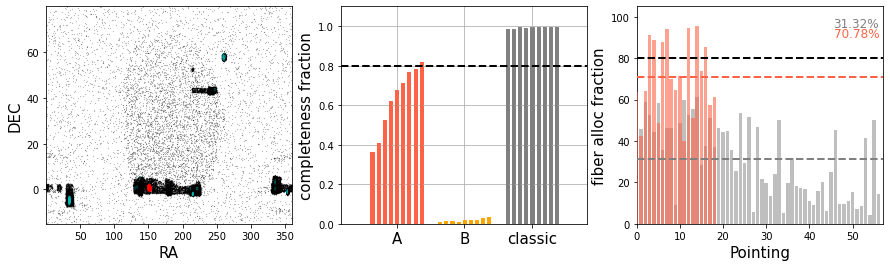

In [141]:
###reference sample:case 3

##the total number of pointing allocated to the open-use programs
npoint=100
##whether to save the final fiber assignment file
writeTF=True
##whether to plot figures of the completed fraction and fiber allocation fraction
plotTF=True
execu(npoint,writeTF,plotTF)

Please input the name of your file:test1_cluster
Please choose the refererence samples: 
 case 1 -- compactly-distributed random mocks (please be careful it can take long time ~30 min); 
 case 2 -- widely-distributed random mocks; 
 case 3 -- simulated real queue 
2
#Please confirm your sample is ['user_s/test1_cluster']
#Step 1/3: Read in samples DONE! (takes 1.123 sec)
#Step 2/3: Determine pointing centers DONE! (takes 3.689 sec)
  Your sample (red) and the reference sample (black), with the pointings (cyan):


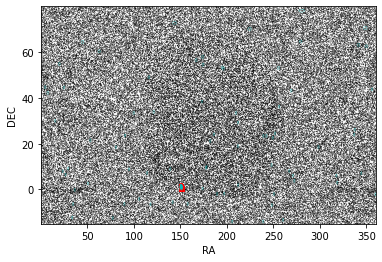

#Step 3/3: Start running netflow to assign fibers
There are 101 pointings, they are grouped into 76 clusters.
##Now is Group 0 , it contains 1 pointings, and 10 targets.
Set parameter Username
Academic license - for non-commercial use only - expires 2023-09-17
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.00%
##Now is Group 1 , it contains 1 pointings, and 4 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.00%
##Now is Group 2 , it cont

Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 14 , it contains 1 pointings, and 17 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.13%
##Now is Group 15 , it contains 1 pointings, and 6 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating

##Now is Group 34 , it contains 1 pointings, and 2 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.00%
##Now is Group 35 , it contains 1 pointings, and 3 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 36 , it contains 1 pointings, and 8 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to va

##Now is Group 55 , it contains 1 pointings, and 5 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.08%
##Now is Group 56 , it contains 1 pointings, and 4 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 57 , it contains 1 pointings, and 2 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to va

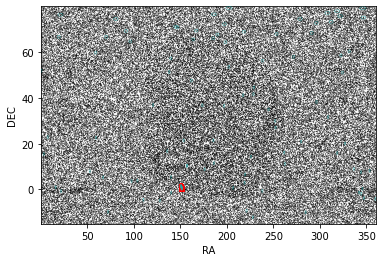

#Step 3/3: Start running netflow to assign fibers
There are 101 pointings, they are grouped into 90 clusters.
##Now is Group 0 , it contains 1 pointings, and 11 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 1 , it contains 10 pointings, and 12947 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding co

Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.08%
##Now is Group 18 , it contains 1 pointings, and 8 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 19 , it contains 1 pointings, and 15 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 20 , it contains 1 pointings, and 4 targets.
Set parameter

adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 39 , it contains 1 pointings, and 20 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.13%
##Now is Group 40 , it contains 1 pointings, and 8 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 41 , it contains 1 pointings, and 4 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set paramet

Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 60 , it contains 1 pointings, and 3 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.00%
##Now is Group 61 , it contains 1 pointings, and 11 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 62 , it contains 1 pointings, and 7 targets.
Set parameter

adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 81 , it contains 1 pointings, and 4 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.04%
##Now is Group 82 , it contains 1 pointings, and 16 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
exposure 0:
  assigned Cobras(%): 0.17%
##Now is Group 83 , it contains 1 pointings, and 30 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parame

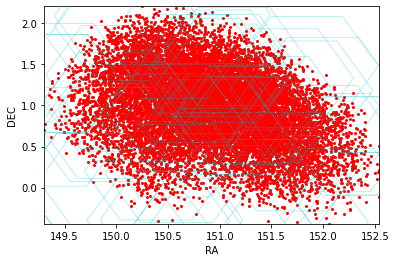

#Step 3/3: Start running netflow to assign fibers
There are 56 pointings, they are grouped into 1 clusters.
##Now is Group 0 , it contains 56 pointings, and 14363 targets.
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding collision constraints
  exposure 4
Calculating visibilities
adding constraints
adding collision constraints
  exposure 5
Calculating visibilities
adding constraints
adding collision constraints
  exposure 6
Calculating visibilities
adding constraints
adding collision constraints
  exposure 7
Calculating visibilities
adding constraints
adding collision constraints
  exposure 8
Calculating 

In [ ]:
###reference sample:case 2

##the total number of pointing allocated to the open-use programs
npoint=100
##whether to save the final fiber assignment file
writeTF=True
##whether to plot figures of the completed fraction and fiber allocation fraction
plotTF=True
execu(npoint,writeTF,plotTF)